In [209]:

labeldict_findstr = {-2: 'unknown',
                     0: 'ground_stationary',
                     1: 'stationary',
                     2: 'bathing',
                     3: 'flying_active',
                     4: 'flying_passive',
                     5: 'foraging'}

label_colors = {
    0: 'red',       # 红色
    1: 'blue',      # 蓝色
    2: 'green',     # 绿色
    3: 'orange',    # 橙色
    4: 'purple',    # 紫色
    5: 'brown',     # 棕色
    6: 'pink',      # 粉色
    7: 'cyan',      # 青色
    8: 'magenta',   # 品红
    9: 'lime',      # 青柠色
    10: 'teal',     # 蓝绿色
    11: 'violet',   # 紫罗兰色
    12: 'gold',     # 金色
    13: 'coral',    # 珊瑚色
    14: 'salmon'    # 三文鱼色
}

In [115]:
def plot_func_new_label_marker(X_labeled_list, X_unlabeled_list,
                               X_labeled_pre_list, y_labeled_list,
                                 y_unlabeled_list, y_labeled_pre_list,
                               name):

    X_labeled = np.concatenate(X_labeled_list)
    X_unlabeled = np.concatenate(X_unlabeled_list)
    X_labeled_pre = np.concatenate(X_labeled_pre_list)

    y_labeled = np.concatenate(y_labeled_list)
    y_labeled = majority_value(y_labeled)
    # y_labeled_str = [labeldict_findstr[i] for i in y_labeled]

    y_unlabeled = np.concatenate(y_unlabeled_list)
    y_unlabeled = majority_value(y_unlabeled)
    # y_unlabeled_str = [labeldict_findstr[i] for i in y_unlabeled]

    y_labeled_pre = np.concatenate(y_labeled_pre_list)
    y_labeled_pre = majority_value(y_labeled_pre)
    # y_labeled_pre_str = [labeldict_findstr[i] for i in y_labeled_pre]

    # 使用 UMAP 降维到二维
    umap_model = UMAP(n_components=2, random_state=0)
    X_unlabeled_umap = umap_model.fit_transform(X_unlabeled)
    X_labeled_umap = umap_model.transform(X_labeled)
    X_labeled_pre_umap = umap_model.transform(X_labeled_pre)


    plt.figure(figsize=(5, 8))
    
    # 绘制未标注数据点
    plt.scatter(X_unlabeled_umap[:, 0], X_unlabeled_umap[:, 1],
                color='lightgray', label='Unlabeled', alpha=0.5)

    # 绘制已标注数据点，根据类别着色
    unique_labels = np.unique(y_unlabeled)
    for label in unique_labels:
        idx = (y_labeled == label)
        plt.scatter(X_labeled_umap[idx, 0],
                    X_labeled_umap[idx, 1],
                    label=f'Update label {labeldict_findstr[label]}',
                    color=label_colors[label],
                    alpha=0.8,
                    marker='o',
                    facecolors='none')  # 这里添加 facecolors='none' 实现空心圆

    # 绘制更新后的已标注数据点
    for label in unique_labels:
        idx = (y_labeled_pre == label)
        plt.scatter(X_labeled_pre_umap[idx, 0],
                    X_labeled_pre_umap[idx, 1],
                    label=f'Previous label {labeldict_findstr[label]}',
                    color=label_colors[label],
                    alpha=0.8, marker='x')

    # 添加图例和标签
    plt.title('UMAP of Latent Representation')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.legend(loc='lower left')
    plt.grid()
    plt.savefig(f'newlabel_{name}.png', bbox_inches='tight')
    plt.close()

    return X_unlabeled_umap, X_labeled_umap, X_labeled_pre_umap, y_unlabeled, y_labeled, y_labeled_pre


In [116]:
def plot_func(X_unlabeled_umap, X_labeled_umap, X_labeled_pre_umap, y_unlabeled, y_labeled, y_labeled_pre, count, name):

    X = np.concatenate([X_unlabeled_umap, X_labeled_umap, X_labeled_pre_umap])
    print(X.shape)
    y = np.concatenate([y_unlabeled, y_labeled, y_labeled_pre])
    print(y.shape)

    # 绘制已标注数据点，根据类别着色
    unique_labels = np.unique(y)
    
    plt.figure(figsize=(5, 8))
    for label in unique_labels:
        idx = (y == label)
        plt.scatter(X[idx, 0],
                    X[idx, 1],
                    label=f'{labeldict_findstr[label]}',
                    color=label_colors[label],
                    s=6,  # 调整点的大小，20 是较小的值
                    alpha=0.3  # 降低透明度，0.5 是较低的透明度
                    )
    # 添加图例和标签
    plt.title('UMAP of Latent Representation - groundtruth labels')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.legend()
    plt.grid()
    plt.savefig('%s_alllabel_epoch_%s.png' % (name, str(count)), bbox_inches='tight')
    plt.close()
    return 


In [184]:
'''
使用2018，21年的数据，使用完全没有初始化的encoder，随机添加label，计算监督学习结果
两个结果：
latent space结果
active learning的F1 score
'''

import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
import pandas as pd
import random
import torch
import pickle
from torch import optim
from torch.utils.data import DataLoader
from umap import UMAP
import plotly.express as px


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score


from deepview.calculate_results.data.umineko.umineko_data import (
    label_dict,
)

from deepview.calculate_results.models.utils import (
    data_loader_umineko,
    Autoencoder3d4,  # debug purpose
    Autoencoder1d,
    majority_value,
)

from scipy.stats import entropy
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

def set_random_seed(seed):
    # Set seed for Python's random module
    random.seed(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    # Set seed for PyTorch
    torch.manual_seed(seed)
    # If using CUDA, set seed for GPU as well
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups


# Set a fixed random seed
seed_value = 2025
set_random_seed(seed_value)


def read_sensor_data():
    raw_data, labeled_data = [], []
    for year in ['2018', '2022']:
        dp = r'D:\code\DeepView\deepview\calculate_results\data\umineko_%s.npy'
        data = np.load(dp % year, allow_pickle=True).item()
        # Access the individual components
        raw_ = data['raw_data']
        labeled_ = data['labeled_data']
        if year == '2018':
            df_raw_2018 = raw_
            df_2018 = labeled_
        # elif year=='2019':
        #     df_raw_2019 = raw_
        #     df_2019 = labeled_
        elif year == '2022':
            df_raw_2022 = raw_
            df_2022 = labeled_
        else:
            print('Error: year not found')
            break

    selected_df = pd.concat([df_raw_2018, df_raw_2022], ignore_index=True)
    selected_df['filename'] = selected_df['year'].astype(int).astype(str) + '_' + selected_df['animal_tag']
    animal_tag_list = ['2018_LB07', '2018_LB08', '2018_LB09', '2018_LB10', '2018_LB11', '2018_LB12', '2018_LB13',
                       '2022_LB02', '2022_LB03', '2022_LB08', '2022_LB09']
    selected_df = selected_df[selected_df['filename'].isin(animal_tag_list)]

    selected_df['label_id'] = selected_df['label'].map(label_dict)
    selected_df['label_id'] = selected_df['label_id'].fillna(-2)

    # 删除无标签的数据
    selected_df = selected_df[selected_df.label_id != -2]
    return selected_df


len_sw = 50
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ======= 1. 数据生成 ======= #
with open(r'D:\code\DeepView\deepview\calculate_results\data\umineko\data.pkl', 'rb') as file:  # 'rb'表示以二进制读取模式打开文件
    d_dict = pickle.load(file)
    data_b = d_dict['data']
    label_b = d_dict['label']

# 将数据分为8:2，其中2为测试集
vote_label = majority_value(label_b)
X_train_full, X_test, y_train_full, y_test = train_test_split(data_b, label_b,
                                                              test_size=0.2, stratify=vote_label,
                                                              random_state=42)

# 从X_train_full中随机选择1%的数据作为X_labeled，其余为X_unlabeled
X_labeled, X_unlabeled, y_labeled, y_unlabeled = train_test_split(X_train_full, y_train_full, test_size=0.99, random_state=42)

# 确保X_labeled和X_unlabeled的大小
print("X_labeled shape:", X_labeled.shape)
print("X_unlabeled shape:", X_unlabeled.shape)
print("X_test shape:", X_test.shape)


# ======= 2. 模型与 Supervised Contrastive Learning ======= #
class SimpleNN(nn.Module):
    def __init__(self, input_dim=128 * 6, embedding_dim=128, number_classes=6):
        super(SimpleNN, self).__init__()
        self.acc_encoder = Autoencoder3d4().feature_extractor
        self.pre_encoder = Autoencoder1d().feature_extractor

        self.linear = nn.Linear(input_dim*2, 32)
        self.projector = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 16)
        )

        self.classifier = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, number_classes),
            nn.Softmax(dim=1),
        )


    def forward(self, data, if_contrast=True):
        accel = data[:, :3, :]
        press = data[:, -1:, :]
        acc_fea, _, _ = self.acc_encoder(accel)
        pre_fea, _, _ = self.pre_encoder(press)
        concat_fea = torch.concat([acc_fea, pre_fea], dim=1)
        concat_fea = self.linear(concat_fea)
        # concat_fea = self.linear(acc_fea)
        if if_contrast:
            output = self.projector(concat_fea)  # output(batch, 128)
        else:
            output = self.classifier(concat_fea)
        return output, concat_fea


class SupContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.3):
        super(SupContrastiveLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        Args:
            features: Tensor of shape [batch_size, feature_dim], normalized embeddings.
            labels: Tensor of shape [batch_size], ground truth labels for the samples.
        Returns:
            loss: Supervised contrastive loss value.
        """
        features = F.normalize(features, dim=1)
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # 数值稳定处理
        similarity_matrix = similarity_matrix - torch.max(similarity_matrix, dim=1, keepdim=True)[0]

        # Positive and negative masks
        labels1 = labels.unsqueeze(1)
        mask = torch.eye(similarity_matrix.size(0), dtype=torch.bool, device=features.device)
        positive_mask = (labels1 == labels1.T) & ~mask

        exp_sim = torch.exp(similarity_matrix)
        numerator = exp_sim * positive_mask
        denominator = exp_sim * ~mask

        numerator_sum = numerator.sum(dim=1) + 1e-8
        denominator_sum = denominator.sum(dim=1) + 1e-8

        valid_mask = numerator_sum > 0  # Skip samples with no positive pairs
        loss = -torch.log(numerator_sum[valid_mask] / denominator_sum[valid_mask])
        loss = loss.mean()

        # # cluster center loss
        # all_loss = combined_loss(latent, labels, loss, lambda_intra=1.0, lambda_inter=10)

        return loss


# ======= 3. 模型训练 ======= #

def train_model(model, loader, criterion, optimizer, epochs=500, device='cpu', if_contrast=True):
    model.train()
    avg_loss = []
    for epoch in range(epochs):
        losses = []
        for batch in loader:
            data, labels = batch
            label_vote = majority_value(labels)
            label_vote = torch.from_numpy(label_vote)

            data = data.to(device=device, dtype=torch.float)
            label_vote = label_vote.to(device=device, dtype=torch.long)
            # outputs: supcontrast output; feature: feature extractor output
            outputs, features = model(data, if_contrast)
            loss = criterion(outputs, label_vote)
            losses.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        avg_loss.append(np.mean(losses))
        # print(f"Epoch {epoch + 1}, Loss: {avg_loss[-1]}")
    return model, avg_loss


def accuracy_class(predict_labels, true_labels):
    # 1. 获取唯一类别
    unique_classes = np.unique(true_labels)

    # 2. 计算每个类别的准确率
    class_accuracies = {}
    for cls in unique_classes:
        # 筛选出属于当前类别的样本
        class_indices = true_labels == cls
        # 计算预测正确的数量和总数量
        correct_predictions = np.sum(predict_labels[class_indices] == true_labels[class_indices])
        total_samples = np.sum(class_indices)
        # 计算准确率
        accuracy = correct_predictions / total_samples if total_samples > 0 else 0
        class_accuracies[cls] = accuracy

    # 输出每个类别的准确率
    for cls, acc in class_accuracies.items():
        print(f"Class {cls}: Accuracy = {acc:.2f}")


def evaluate_model(model, loader):
    # supervised learning
    model.eval()
    ground_truth, prediction = [], []
    data_list, predlabel_list, truelabel_list = [], [], []  # 保存新标签用于supCon训练
    with (torch.no_grad()):
        for data, labels in loader:
            data = data.to(device=device, dtype=torch.float)
            label_vote = majority_value(labels)
            label_vote = torch.from_numpy(label_vote)
            label_vote = label_vote.to(device=device, dtype=torch.long)
            predicts, features = model(data, if_contrast=False)
            max_values, predictions = torch.max(predicts, dim=1)  # max_values用来挑选threshold
            ground_truth.append(label_vote.detach().cpu().numpy())
            prediction.append(predictions.detach().cpu().numpy())
            data_list.append(data.detach().cpu().numpy())

    # 计算准确率
    accuracy = accuracy_score(np.concatenate(ground_truth, axis=0), np.concatenate(prediction, axis=0))
    # print(f'Accuracy: {accuracy:.2f}, Macro F1 Score: {macro_f1:.2f}, Micro F1 Score: {micro_f1:.2f}')
    # 计算 macro F1 分数
    macro_f1 = f1_score(np.concatenate(ground_truth, axis=0), np.concatenate(prediction, axis=0), average='macro')
    # print(f'Macro F1 Score: {macro_f1:.2f}')
    # 计算 micro F1 分数
    micro_f1 = f1_score(np.concatenate(ground_truth, axis=0), np.concatenate(prediction, axis=0), average='micro')
    # print(f'Micro F1 Score: {micro_f1:.2f}')
    print(f'Accuracy: {accuracy:.2f}, Macro F1 Score: {macro_f1:.2f}, Micro F1 Score: {micro_f1:.2f}')
    return accuracy, macro_f1, micro_f1, prediction, ground_truth


def evaluate_supContrast_model(model, loader, cal_threshold=0.0):
    model.eval()
    correct, total = 0, 0
    threshold_acc, threshold_total = 0, 0
    data_list, predlabel_list, truelabel_list = [], [], []  # 保存新标签用于supCon训练
    with torch.no_grad():
        for data, labels in loader:
            data = data.to(device=device, dtype=torch.float)
            label_vote = majority_value(labels)
            label_vote = torch.from_numpy(label_vote)
            label_vote = label_vote.to(device=device, dtype=torch.long)
            predicts, features = model(data, if_contrast=False)
            max_values, predictions = torch.max(predicts, dim=1)  # max_values用来挑选threshold
            correct += (predictions == label_vote).sum().item()

            ## 计算预测值大于cal_threshold前提下的准确率
            # 将 max_values 小于 cal_threshold 的位置上的 max_indices 赋值为 -1
            predictions[max_values < cal_threshold] = -1
            threshold_acc += (predictions == label_vote).sum().item()
            # # 计算 predictions 中 -1 的个数
            # count_neg_ones = (predictions == -1).sum().item()

            ## 保存新标签和数据
            # 获取 predictions 中 -1 的位置
            pos_positions = torch.nonzero(predictions != -1).squeeze()  # squeeze() 去掉多余的维度
            if len(pos_positions) > 0:
                new_data = data[pos_positions].detach().cpu().numpy()
                data_list.append(new_data)

                new_label = predictions[pos_positions].detach().cpu().numpy()
                # reshaped_array = new_label.reshape(new_label.shape[0], 1)  # 将形状从 (batch,) 转换为 (batch, 1)
                # reshaped_array = np.tile(reshaped_array, (1, labels.shape[1]))  # 复制到 (batch, 50)

                t_label = label_vote[pos_positions].detach().cpu().numpy()
                # reshaped_t = t_label.reshape(t_label.shape[0], 1)  # 将形状从 (batch,) 转换为 (batch, 1)
                # reshaped_t = np.tile(reshaped_t, (1, labels.shape[1]))  # 复制到 (batch, 50)

                predlabel_list.append(new_label)
                truelabel_list.append(t_label)
            else:
                data_list.append(data.detach().cpu().numpy())

                new_label = predictions.detach().cpu().numpy()
                # reshaped_array = new_label.reshape(labels.shape[0], 1)  # 将形状从 (batch,) 转换为 (batch, 1)
                # reshaped_array = np.tile(reshaped_array, (1, labels.shape[1]))
                predlabel_list.append(new_label)

                truelabel_list.append(label_vote.detach().cpu().numpy())

    # 重新组合 data和label
    concat_data = np.concatenate(data_list, axis=0)
    concat_label = np.concatenate(predlabel_list, axis=0)
    true_label = np.concatenate(truelabel_list, axis=0)
    # 计算准确率
    accuracy = accuracy_score(true_label, concat_label)
    # print(f'Accuracy: {accuracy:.2f}, Macro F1 Score: {macro_f1:.2f}, Micro F1 Score: {micro_f1:.2f}')
    # 计算 macro F1 分数
    macro_f1 = f1_score(true_label, concat_label, average='macro')
    # print(f'Macro F1 Score: {macro_f1:.2f}')
    # 计算 micro F1 分数
    micro_f1 = f1_score(true_label, concat_label, average='micro')
    # print(f'Micro F1 Score: {micro_f1:.2f}')
    print(f'Accuracy: {accuracy:.2f}, Macro F1 Score: {macro_f1:.2f}, Micro F1 Score: {micro_f1:.2f}')
    return (accuracy, macro_f1, micro_f1,  # accuracy
            concat_data, concat_label, true_label)  # label


# ======= 5. 循环主动学习 ======= #
# 初始化模型和优化器
model = SimpleNN()
model = model.to(device)
classify_criterion = nn.CrossEntropyLoss()
supContrast_criterion = SupContrastiveLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)


def AE_eval_time_series(train_loader, model, device):
    model.eval()

    representation_list = []
    sample_list, timestamp_list, label_list, pred_list, timestr_list, flag_list = [], [], [], [], [], []
    for i, (sample, label) in enumerate(train_loader):
        sample = sample.to(device=device, non_blocking=True, dtype=torch.float)
        # input of autoencoder will be 3D, the backbone is 1d-cnn
        output, x_encoded = model(sample)  # x_encoded.shape=batch512,outchannel128,len13
        tmp_representation = x_encoded.detach().cpu().numpy()
        representation_list.append(tmp_representation)
        sample_list.append(sample.detach().cpu().numpy())
        label_list.append(label.detach().cpu().numpy())
        pred_list.append(output.detach().cpu().numpy())

    return representation_list, sample_list, pred_list, label_list


# ---------- 主动学习，sample选择策略 ---------- #
# todo: 需要确定选出来的sample到底具有什么特点

def random_sampling(X_unlabeled, y_unlabeled, update_size):
    select_size = min(update_size, len(X_unlabeled))
    selected_indices = np.random.choice(len(X_unlabeled), select_size, replace=False)
    selected_samples = X_unlabeled[selected_indices]
    selected_labels = y_unlabeled[selected_indices]
    X_unlabeled = np.delete(X_unlabeled, selected_indices, axis=0)
    y_unlabeled = np.delete(y_unlabeled, selected_indices, axis=0)
    return selected_samples, selected_labels, X_unlabeled, y_unlabeled

def freeze_encoders(model):
    for param in model.acc_encoder.parameters():
        param.requires_grad = False
    for param in model.pre_encoder.parameters():
        param.requires_grad = False
    for param in model.linear.parameters():
        param.requires_grad = False
    for param in model.projector.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

def freeze_projector(model):
    for param in model.acc_encoder.parameters():
        param.requires_grad = True
    for param in model.pre_encoder.parameters():
        param.requires_grad = True
    for param in model.linear.parameters():
        param.requires_grad = True
    for param in model.projector.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

# 解冻特征提取器函数：stage1，训练对比损失
def unfreeze_encoders(model):
    for param in model.acc_encoder.parameters():
        param.requires_grad = True
    for param in model.pre_encoder.parameters():
        param.requires_grad = True
    for param in model.linear.parameters():
        param.requires_grad = True
    for param in model.projector.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = False

def unfreeze_all(model):
    for param in model.acc_encoder.parameters():
        param.requires_grad = True
    for param in model.pre_encoder.parameters():
        param.requires_grad = True
    for param in model.linear.parameters():
        param.requires_grad = True
    for param in model.projector.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True


def compute_loss_contribution(model, unlabeled_data, labeled_data, labeled_labels):
    model.eval()
    with torch.no_grad():
        # 计算未标注数据和已标注数据的嵌入
        _, unlabeled_embeddings = model(torch.tensor(unlabeled_data, device=device, dtype=torch.float32),
                                        if_contrast=True)
        _, labeled_embeddings = model(torch.tensor(labeled_data, device=device, dtype=torch.float32), if_contrast=True)

        # 计算相似性矩阵 (unlabeled x labeled)
        similarities = torch.matmul(unlabeled_embeddings, labeled_embeddings.T)
        label_vote = majority_value(labeled_labels)
        label_vote = torch.from_numpy(label_vote)
        labeled_labels = label_vote.to(device=device, dtype=torch.long)

        loss_contributions = []
        for i, sim in enumerate(similarities):  # 遍历未标注样本
            # 获取与已标注数据的正负样本掩码
            pos_mask = (labeled_labels == labeled_labels[i % len(labeled_labels)]).float()
            neg_mask = 1 - pos_mask

            # 避免掩码全为 0
            if pos_mask.sum() == 0:
                pos_mask[torch.argmax(sim)] = 1
            if neg_mask.sum() == 0:
                neg_mask[torch.argmin(sim)] = 1

            # 归一化相似性以避免指数计算溢出
            sim = sim - sim.max()  # 数值稳定性优化

            # 正样本损失
            pos_sim = sim * pos_mask
            pos_loss = -torch.logsumexp(pos_sim, dim=-1) + torch.logsumexp(sim, dim=-1)  # 使用 logsumexp 避免显式指数计算

            # 负样本损失
            neg_sim = sim * neg_mask
            neg_loss = -torch.logsumexp(neg_sim, dim=-1) + torch.logsumexp(sim, dim=-1)

            # 合并正负样本损失
            total_loss = pos_loss + neg_loss
            loss_contributions.append(total_loss.item())

    return np.array(loss_contributions)

def supContrast_contribution(X_labeled, y_labeled, X_unlabeled, y_unlabeled, model, update_size):
    # 计算每个样本的贡献度
    ## 计算未标注数据（all-labeled-test）的对比损失贡献
    loss_contributions = compute_loss_contribution(model, X_unlabeled, X_labeled, y_labeled)

    # 选择贡献度最大的样本
    selected_indices = np.argsort(loss_contributions)[-update_size:]
    selected_samples = X_unlabeled[selected_indices]
    selected_labels = y_unlabeled[selected_indices]
    ## 更新标注集和未标注数据池
    X_labeled = np.vstack([X_labeled, selected_samples])
    y_labeled = np.concatenate([y_labeled, selected_labels], axis=0)
    X_unlabeled = np.delete(X_unlabeled, selected_indices, axis=0)
    y_unlabeled = np.delete(y_unlabeled, selected_indices, axis=0)
    print(f"Labeled samples: {len(X_labeled)}")

    return X_labeled, y_labeled, X_unlabeled, y_unlabeled


# 计算样本不确定性（基于熵）
def uncertainty_sampling(X_labeled, y_labeled, X_unlabeled, y_unlabeled, model, update_size):
    model.eval()
    with torch.no_grad():
        # 计算未标注数据和已标注数据的嵌入
        _, unlabeled_embeddings = model(torch.tensor(X_unlabeled, device=device, dtype=torch.float32),
                                        if_contrast=True)
        probs = model.classifier(unlabeled_embeddings)

        uncertainty = entropy(probs.detach().cpu().numpy().T)  # 计算每个样本的熵

        # 选择贡献度最大的样本
        selected_indices = np.argsort(uncertainty)[-update_size:]
        selected_samples = X_unlabeled[selected_indices]
        selected_labels = y_unlabeled[selected_indices]
        ## 更新标注集和未标注数据池
        X_labeled = np.vstack([X_labeled, selected_samples])
        y_labeled = np.concatenate([y_labeled, selected_labels], axis=0)
        X_unlabeled = np.delete(X_unlabeled, selected_indices, axis=0)
        y_unlabeled = np.delete(y_unlabeled, selected_indices, axis=0)
        print(f"Labeled samples: {len(X_labeled)}")

        return X_labeled, y_labeled, X_unlabeled, y_unlabeled, selected_labels


# ---------- 主动学习，sample选择策略 ---------- #
SupCount = 1  # supcontrastive learning
warmup = 20  # warmup epoch of supcontrastive learning
name_label = '_entropy_Contrast%s_warm%s'%(str(SupCount), str(warmup))
sensor_type = 'AccelPress'
# 主动学习迭代
update_size = max(int(0.01 * len(X_train_full)), 2)  # 每次选择 1% 的样本
batch_size = 4000
iteration = 1

## 创建数据加载器
plot_dataset = data_loader_umineko(data_b.astype(float), label_b.astype(int))
plot_loader = DataLoader(plot_dataset, batch_size=batch_size, shuffle=True, drop_last=False)

train_accuracy_list, train_macro_f1_list, train_micro_f1_list = [], [], []
test_accuracy_list, test_macro_f1_list, test_micro_f1_list = [], [], []
test_pred_label_lists, test_truth_label_lists = [], []
weight_list, loss_list, selected_labels_list = [], [], []
ari_list, nmi_list, fmi_list, silhouette_list = [], [], [], []
while len(X_unlabeled) > 0:
    print(f"==============Iteration {iteration}===============")
    print(f"Already labeled samples: {len(y_labeled)}")
    print(f"Remaining unlabeled samples: {len(y_unlabeled)}")

    # 创建数据加载器
    labeled_dataset = data_loader_umineko(X_labeled.astype(float), y_labeled.astype(int))
    labeled_loader = DataLoader(labeled_dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    ## stage 1: train supCon model (所有数据都来训练)
    unfreeze_encoders(model)
    if iteration < warmup:
        epoch = 500
        model, _ = train_model(model, labeled_loader, supContrast_criterion, optimizer,
                                      epochs=epoch, device=device, if_contrast=True)

    ## stage 2: train supervised model, 获得分类器新参数
    freeze_encoders(model)  # only classifier is trainable
    model, _ = train_model(model, labeled_loader, classify_criterion, optimizer,
                                  epochs=10, device=device, if_contrast=False)
    freeze_projector(model)  # only projector is NOT trainable
    model, avg_loss = train_model(model, labeled_loader, classify_criterion, optimizer,
                            epochs=50, device=device, if_contrast=False)
    loss_list.append(np.average(avg_loss))  # 记录50次epoch的平均loss


    # ======= 6. 模型测试 ======= #
    print('-------Training----------')
    accuracy, macro_f1, micro_f1, pred_label_list, truth_label_list = evaluate_model(model, labeled_loader)
    train_accuracy_list.append(accuracy)
    train_macro_f1_list.append(macro_f1)
    train_micro_f1_list.append(micro_f1)

    test_dataset = data_loader_umineko(X_test.astype(float), y_test.astype(int))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
    print('-------Test----------')
    (accuracy, macro_f1, micro_f1,
     rest_datan, pred_label_list, truth_label_list) = (
        evaluate_supContrast_model(model, test_loader, cal_threshold=0.5))
    test_accuracy_list.append(accuracy)
    test_micro_f1_list.append(micro_f1)
    test_macro_f1_list.append(macro_f1)
    test_pred_label_lists.append(pred_label_list)
    test_truth_label_lists.append(truth_label_list)


    # 保存当前模型权重到列表
    weight_list.append(model.state_dict())

    # # stage 3: 更新数据集
    select_size = min(update_size, len(X_unlabeled))

    ### uncertainty_sampling
    X_labeled_pre = X_labeled.copy()
    y_labeled_pre = y_labeled.copy()
    X_labeled, y_labeled, X_unlabeled, y_unlabeled, selected_labels = (
        uncertainty_sampling(X_labeled, y_labeled,
                             X_unlabeled, y_unlabeled,
                             model, select_size))  # data变化了
    selected_labels_list.append(selected_labels)
    
     ### plot
    if iteration == 2:
        ## 原先已有的标签
        xlabelpre_dataset = data_loader_umineko(X_labeled_pre.astype(float),
                                        y_labeled_pre.astype(int))
        xlabelpre_loader = DataLoader(xlabelpre_dataset,
                                      batch_size=batch_size,
                                      shuffle=False, drop_last=False)
        X_labeled_pre_list, _, _, y_labeled_pre_list = \
                    AE_eval_time_series(xlabelpre_loader, model, device)
        ## 新增标签
        X_labeled_new = X_labeled[-select_size:]
        y_labeled_new = y_labeled[-select_size:]
        xlabel_dataset = data_loader_umineko(X_labeled_new.astype(float),
                                                y_labeled_new.astype(int))
        xlabel_loader = DataLoader(xlabel_dataset,
                                      batch_size=batch_size,
                                      shuffle=False, drop_last=False)
        X_labeled_list, _, _, y_labeled_list = \
            AE_eval_time_series(xlabel_loader, model, device)
        ## 
        xunlabel_dataset = data_loader_umineko(X_unlabeled.astype(float),
                                                y_unlabeled.astype(int))
        xunlabel_loader = DataLoader(xunlabel_dataset,
                                      batch_size=batch_size,
                                      shuffle=False, drop_last=False)
        X_unlabeled_list, _, _, y_unlabeled_list = \
            AE_eval_time_series(xunlabel_loader, model, device)

        X_unlabeled_umap, X_labeled_umap, X_labeled_pre_umap, y_unlabeled_umap, y_labeled_new_umap, y_labeled_pre_umap = (
            plot_func_new_label_marker(X_labeled_list, X_unlabeled_list,
                                   X_labeled_pre_list, y_labeled_list,
                                   y_unlabeled_list, y_labeled_pre_list,
                                   name='_proposed_newlabel_%s'%str(iteration)))

        plot_func(X_unlabeled_umap, X_labeled_umap, X_labeled_pre_umap, y_unlabeled_umap, y_labeled_new_umap, y_labeled_pre_umap, iteration, 'AccelPress')
        break

    iteration += 1

print(iteration)
print("All unlabeled samples have been labeled!")


X_labeled shape: (59, 4, 50)
X_unlabeled shape: (5891, 4, 50)
X_test shape: (1488, 4, 50)
==============Iteration 1===============
Already labeled samples: 59
Remaining unlabeled samples: 5891
-------Training----------
Accuracy: 0.97, Macro F1 Score: 0.90, Micro F1 Score: 0.97
-------Test----------
Accuracy: 0.82, Macro F1 Score: 0.48, Micro F1 Score: 0.82
Labeled samples: 118
==============Iteration 2===============
Already labeled samples: 118
Remaining unlabeled samples: 5832
-------Training----------
Accuracy: 1.00, Macro F1 Score: 1.00, Micro F1 Score: 1.00
-------Test----------
Accuracy: 0.82, Macro F1 Score: 0.54, Micro F1 Score: 0.82
Labeled samples: 177


D:\Users\dell\anaconda3\envs\deepviewbackup\lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Already labeled samples: 177
(5950, 2)
(5950,)
Already labeled samples: 177
2
All unlabeled samples have been labeled!


## 查看个别样本

In [119]:
label_colors2 = {
    '0': 'red',       # 红色
    '1': 'blue',      # 蓝色
    '2': 'green',     # 绿色
    '3': 'orange',    # 橙色
    '4': 'purple',    # 紫色
    '5': 'brown',     # 棕色
    '6': 'pink',      # 粉色
    'List 1': 'lightgray'
}

In [120]:

X = np.concatenate([X_unlabeled_umap, X_labeled_umap])
# print(X.shape)
y = np.concatenate([y_unlabeled, y_labeled])
# print(y.shape)
list_label = ['List 1'] * len(X_unlabeled_umap) + [str(i) for i in y_labeled]
index_label = [i for i in range(len(X_unlabeled_umap))] + [i for i in range(len(X_labeled_umap))] 


# X = np.concatenate([X_unlabeled_umap, X_labeled_umap, X_labeled_pre_umap])
# # print(X.shape)
# y = np.concatenate([y_unlabeled, y_labeled, y_labeled_pre])
# # print(y.shape)
# list_label = ['List 1'] * len(X_unlabeled_umap) + ['List 2'] * len(X_labeled_umap) + ['List 3'] * len(X_labeled_pre_umap)
# index_label = [i for i in range(len(X_unlabeled_umap))] + [i for i in range(len(X_labeled_umap))] + [i for i in range(len(X_labeled_pre_umap))] 


# 创建 DataFrame
df = pd.DataFrame({
    'x1': X[:,0],
    'x2': X[:,1],
    'y': list_label,
    'index_label': index_label
})

# 创建散点图
fig = px.scatter(
    df,
    x='x1',
    y='x2',
    color='y',  # 根据 x 列的值给点上色
    color_discrete_map=label_colors2,
    hover_name='index_label',  # 鼠标悬停时显示标签
    title='Scatter Plot of Three Lists'
)

# 显示图形
fig.show()

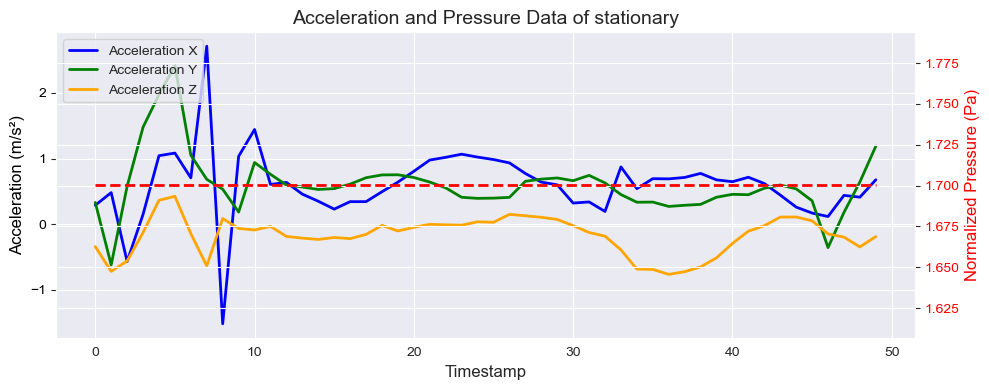

In [153]:
# 提取加速度和压力数据
index = 56
xnew = X_labeled[index]
ynew = y_labeled[index]
acceleration_x = xnew[0, :]
acceleration_y = xnew[1, :]
acceleration_z = xnew[2, :]
pressure = xnew[3, :]

# 创建图形
fig, ax1 = plt.subplots(figsize=(10, 4))

# 绘制加速度数据
ax1.plot(acceleration_x, label='Acceleration X', color='blue', linewidth=2)
ax1.plot(acceleration_y, label='Acceleration Y', color='green', linewidth=2)
ax1.plot(acceleration_z, label='Acceleration Z', color='orange', linewidth=2)

# 设置左侧y轴
ax1.set_ylabel('Acceleration (m/s²)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xlabel('Timestamp', fontsize=12)
ax1.set_title('Acceleration and Pressure Data of %s'%labeldict_findstr[ynew], fontsize=14)

# 添加图例
ax1.legend(loc='upper left')

# 创建右侧y轴
ax2 = ax1.twinx()
ax2.plot(pressure, label='Pressure', color='red', linestyle='--', linewidth=2)
ax2.set_ylabel('Normalized Pressure (Pa)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# 美化图形
fig.tight_layout()  # 自动调整子图参数
plt.grid(visible=True)
# 保存为PDF文件
plt.savefig('accpres_newlabel_iter2_%s.pdf'%labeldict_findstr[ynew], format='pdf', dpi=300)

plt.show()

In [122]:

X = np.concatenate([X_unlabeled_umap, X_labeled_pre_umap])
# print(X.shape)
y = np.concatenate([y_unlabeled, y_labeled_pre])
# print(y.shape)
list_label = ['List 1'] * len(X_unlabeled_umap) + [str(i) for i in y_labeled_pre]
index_label = [i for i in range(len(X_unlabeled_umap))] + [i for i in range(len(X_labeled_pre_umap))] 


# 创建 DataFrame
df = pd.DataFrame({
    'x1': X[:,0],
    'x2': X[:,1],
    'y': list_label,
    'index_label': index_label
})

# 创建散点图
fig = px.scatter(
    df,
    x='x1',
    y='x2',
    color='y',  # 根据 x 列的值给点上色
    color_discrete_map=label_colors2,
    hover_name='index_label',  # 鼠标悬停时显示标签
    title='Scatter Plot of Three Lists'
)

# 显示图形
fig.show()

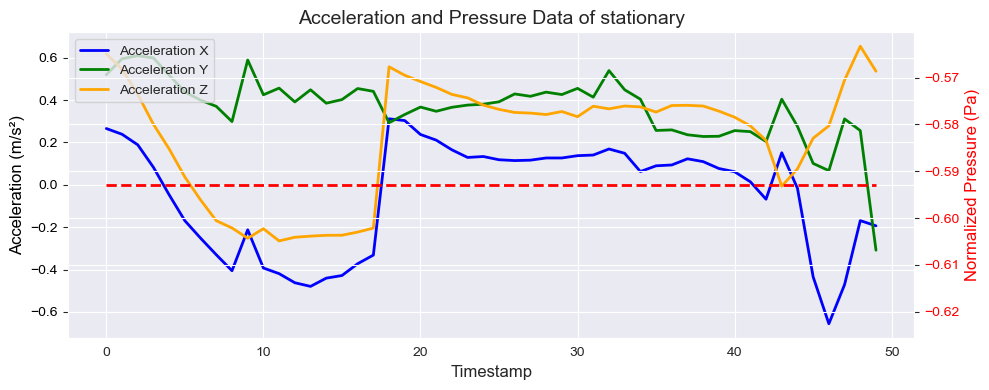

In [154]:
# 提取加速度和压力数据
index = 106
xpre = X_labeled_pre[index]
ypre = y_labeled_pre[index]
acceleration_x = xpre[0, :]
acceleration_y = xpre[1, :]
acceleration_z = xpre[2, :]
pressure = xpre[3, :]

# 创建图形
fig, ax1 = plt.subplots(figsize=(10, 4))

# 绘制加速度数据
ax1.plot(acceleration_x, label='Acceleration X', color='blue', linewidth=2)
ax1.plot(acceleration_y, label='Acceleration Y', color='green', linewidth=2)
ax1.plot(acceleration_z, label='Acceleration Z', color='orange', linewidth=2)

# 设置左侧y轴
ax1.set_ylabel('Acceleration (m/s²)', color='black', fontsize=12)
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xlabel('Timestamp', fontsize=12)
ax1.set_title('Acceleration and Pressure Data of %s'%labeldict_findstr[ypre], fontsize=14)

# 添加图例
ax1.legend(loc='upper left')

# 创建右侧y轴
ax2 = ax1.twinx()
ax2.plot(pressure, label='Pressure', color='red', linestyle='--', linewidth=2)
ax2.set_ylabel('Normalized Pressure (Pa)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

# 美化图形
fig.tight_layout()  # 自动调整子图参数
plt.grid(visible=True)
# 保存为PDF文件
plt.savefig('accpres_prelabel_iter2_%s.pdf'%labeldict_findstr[ynew], format='pdf', dpi=300)
plt.show()

## 比较新增样本和原样本的分布

In [203]:
# standard deviation
# 之前的样本
pre_std = {}
unique_label = np.unique(y_labeled_pre_umap)
for label in unique_label:
    pre_std[label] = []
    idx = (y_labeled_pre_umap == label)
    tmp_data = X_labeled_pre[idx,:,:]
    for didx in range(tmp_data.shape[0]):
        d = tmp_data[didx,:,:]
        pre_std[label].append(np.std(d))
        
new_std = {}
X_labeled_new = X_labeled[-select_size:]  # 新样本，在最后
unique_label = np.unique(y_labeled_new_umap)
for label in unique_label:
    new_std[label] = []
    idx = (y_labeled_new_umap == label)
    tmp_data = X_labeled_new[idx,:,:]
    for didx in range(tmp_data.shape[0]):
        d = tmp_data[didx,:,:]
        new_std[label].append(np.std(d))

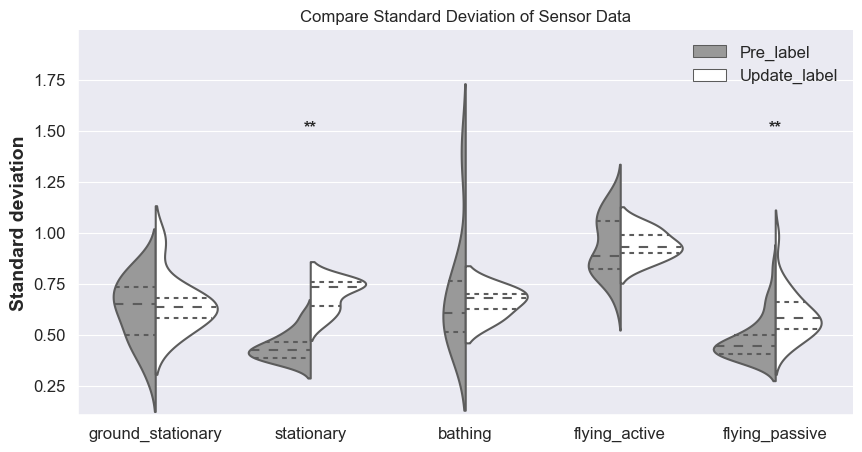

'standard_deviation_violin_plot.pdf'

In [215]:
import matplotlib as mpl

# 设置 Nature 杂志风格
mpl.rcParams['pdf.fonttype'] = 42  # 确保 PDF 矢量图不嵌入字体
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams["font.family"] = "Arial"  # 使用常见的 Nature 期刊字体
mpl.rcParams["axes.linewidth"] = 1.2  # 轴线加粗
mpl.rcParams["xtick.direction"] = "out"  # X 轴刻度朝外
mpl.rcParams["ytick.direction"] = "out"  # Y 轴刻度朝外
mpl.rcParams["xtick.major.size"] = 5  # X 轴主刻度尺寸
mpl.rcParams["ytick.major.size"] = 5  # Y 轴主刻度尺寸

# 生成随机数据，假设 pre_std 和 new_std 分别代表五组数据的标准差
num_pairs = 5

# 组织数据
data = []
for i in range(num_pairs):
    pre = pre_std[i]
    upd = new_std[i]
    pair_label = labeldict_findstr[i]
    data.append(pd.DataFrame({
        'Standard deviation': np.concatenate([pre, upd]),
        'Activity': ['Pre_label'] * len(pre) + ['Update_label'] * len(upd),
        'Pair': pair_label
    }))

# 合并数据
df_multi = pd.concat(data, ignore_index=True)

# 创建图表
plt.figure(figsize=(10, 5))  # 设置合适的比例
sns.violinplot(x='Pair', y='Standard deviation', hue='Activity', data=df_multi, 
               split=True, inner='quartile', palette=["#999999", "#FFFFFF"])

# 统计检验并添加显著性标记
for i, pair in enumerate(df_multi['Pair'].unique()):
    control_values = df_multi[(df_multi['Pair'] == pair) & (df_multi['Activity'] == 'Pre_label')]['Standard deviation']
    preexposed_values = df_multi[(df_multi['Pair'] == pair) & (df_multi['Activity'] == 'Update_label')]['Standard deviation']
    t_stat, p_val = ttest_ind(control_values, preexposed_values, equal_var=False)
    significance = "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    plt.text(i, max(df_multi["Standard deviation"]) + 0.1, significance, ha='center', fontsize=12, fontweight='bold')

# 进一步优化图表美观性
plt.ylim(min(df_multi["Standard deviation"]) - 0.2, max(df_multi["Standard deviation"]) + 0.6)
# plt.ylim(min(df_multi["Standard deviation"]) - 0.2, max(df_multi["Standard deviation"]) + 0.2)
# plt.xlabel("Pair", fontsize=14, fontweight='bold')
plt.xlabel("")  # 移除横轴标题
plt.ylabel("Standard deviation", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, title_fontsize=12, frameon=False)
plt.title('Compare Standard Deviation of Sensor Data', fontsize=12)
sns.despine()  # 去掉顶部和右侧的边框

# 保存为 PDF 矢量图
pdf_path = "standard_deviation_violin_plot.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

# 显示图表
plt.show()

# 返回 PDF 文件路径
pdf_path


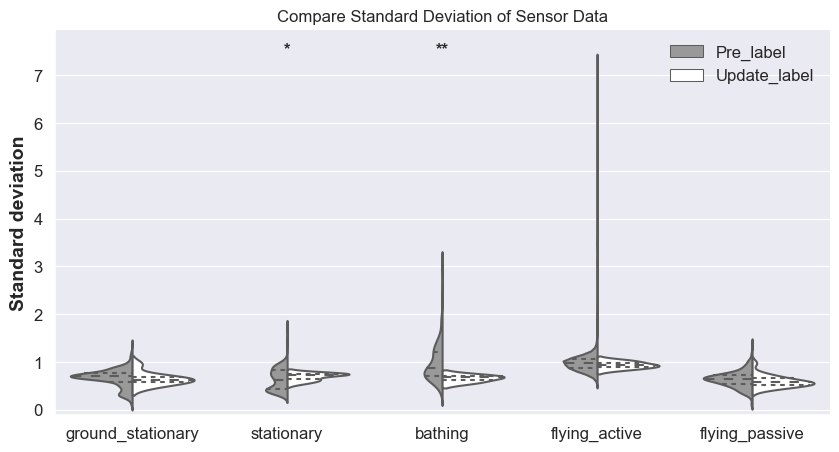

'standard_deviation_violin_plot22.pdf'

In [216]:
# standard deviation
# 之前的样本
pre_std1 = {}
unique_label = np.unique(y_unlabeled_umap)
for label in unique_label:
    pre_std1[label] = []
    idx = (y_unlabeled_umap == label)
    tmp_data = X_unlabeled[idx,:,:]
    for didx in range(tmp_data.shape[0]):
        d = tmp_data[didx,:,:]
        pre_std1[label].append(np.std(d))
        
new_std = {}
X_labeled_new = X_labeled[-select_size:]  # 新样本，在最后
unique_label = np.unique(y_labeled_new_umap)
for label in unique_label:
    new_std[label] = []
    idx = (y_labeled_new_umap == label)
    tmp_data = X_labeled_new[idx,:,:]
    for didx in range(tmp_data.shape[0]):
        d = tmp_data[didx,:,:]
        new_std[label].append(np.std(d))
        
# 设置 Nature 杂志风格
mpl.rcParams['pdf.fonttype'] = 42  # 确保 PDF 矢量图不嵌入字体
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams["font.family"] = "Arial"  # 使用常见的 Nature 期刊字体
mpl.rcParams["axes.linewidth"] = 1.2  # 轴线加粗
mpl.rcParams["xtick.direction"] = "out"  # X 轴刻度朝外
mpl.rcParams["ytick.direction"] = "out"  # Y 轴刻度朝外
mpl.rcParams["xtick.major.size"] = 5  # X 轴主刻度尺寸
mpl.rcParams["ytick.major.size"] = 5  # Y 轴主刻度尺寸

# 生成随机数据，假设 pre_std 和 new_std 分别代表五组数据的标准差
num_pairs = 5

# 组织数据
data = []
for i in range(num_pairs):
    pre = pre_std1[i]
    upd = new_std[i]
    pair_label = labeldict_findstr[i]
    data.append(pd.DataFrame({
        'Standard deviation': np.concatenate([pre, upd]),
        'Activity': ['Pre_label'] * len(pre) + ['Update_label'] * len(upd),
        'Pair': pair_label
    }))

# 合并数据
df_multi = pd.concat(data, ignore_index=True)

# 创建图表
plt.figure(figsize=(10, 5))  # 设置合适的比例
sns.violinplot(x='Pair', y='Standard deviation', hue='Activity', data=df_multi, 
               split=True, inner='quartile', palette=["#999999", "#FFFFFF"])

# 统计检验并添加显著性标记
for i, pair in enumerate(df_multi['Pair'].unique()):
    control_values = df_multi[(df_multi['Pair'] == pair) & (df_multi['Activity'] == 'Pre_label')]['Standard deviation']
    preexposed_values = df_multi[(df_multi['Pair'] == pair) & (df_multi['Activity'] == 'Update_label')]['Standard deviation']
    t_stat, p_val = ttest_ind(control_values, preexposed_values, equal_var=False)
    significance = "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    plt.text(i, max(df_multi["Standard deviation"]) + 0.1, significance, ha='center', fontsize=12, fontweight='bold')

# 进一步优化图表美观性
plt.ylim(min(df_multi["Standard deviation"]) - 0.2, max(df_multi["Standard deviation"]) + 0.6)
# plt.ylim(min(df_multi["Standard deviation"]) - 0.2, max(df_multi["Standard deviation"]) + 0.2)
# plt.xlabel("Pair", fontsize=14, fontweight='bold')
plt.xlabel("")  # 移除横轴标题
plt.ylabel("Standard deviation", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, title_fontsize=12, frameon=False)
plt.title('Compare Standard Deviation of Sensor Data', fontsize=12)
sns.despine()  # 去掉顶部和右侧的边框

# 保存为 PDF 矢量图
pdf_path = "standard_deviation_violin_plot22.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")

# 显示图表
plt.show()

# 返回 PDF 文件路径
pdf_path
